# Sentiment Analysis of Airline Tweets (NLP + Machine Learning)

This notebook presents an end-to-end sentiment analysis workflow applied to tweets about airline services. The goal is to build a reproducible machine learning pipeline capable of classifying tweets into **negative, neutral, or positive sentiment**.

The analysis combines **traditional NLP techniques** (TF-IDF vectorization and linear models) with **exploratory text analysis and lexicon-based sentiment scoring** (VADER). This approach allows us to both evaluate predictive performance and gain insights into the language used in customer feedback.

Dataset:
- Source: Twitter US Airline Sentiment dataset
- Unit of analysis: individual tweets
- Target variable: `airline_sentiment`

Main steps covered in this notebook:

1. Data loading and exploratory data analysis (EDA)
2. Text preprocessing
3. Feature engineering with TF-IDF
4. Baseline model training
5. Model comparison and hyperparameter tuning
6. Error analysis
7. Lexicon-based sentiment analysis (VADER)
8. NLP visualizations and interpretation

Sentiment expressed in social media provides a behavioral signal of
customer experience. Modeling these expressions allows us to identify
patterns of dissatisfaction related to operational failures such as
delays or cancellations.

## 0) Setup

In this section we import the libraries required for data manipulation, visualization, machine learning, and natural language processing.

We also initialize external resources used in the analysis. In particular, we download the **VADER sentiment lexicon**, which is required to compute rule-based sentiment scores later in the notebook.

A fixed `RANDOM_STATE` is used throughout the notebook to ensure reproducibility of the results.


In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer


nltk.download("vader_lexicon")

sid = SentimentIntensityAnalyzer()

RANDOM_STATE = 42

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1) Load Data

The dataset is loaded from a CSV file containing tweets related to several airline companies.

At this stage we verify:

- the shape of the dataset,
- the presence of key variables such as `text` and `airline_sentiment`,
- and inspect a few sample rows to ensure that the data was read correctly.

This step helps confirm that the dataset is ready for further analysis.

In [2]:
df = pd.read_csv("Tweets.csv")
print(df.shape)
df.head()

(14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 2) Exploratory Data Analysis (EDA)

Before training any models, we explore the structure of the dataset to understand the distribution of the target variable and basic characteristics of the tweets.

Key aspects explored in this section include:

- **Sentiment distribution:** to identify whether the dataset is balanced or dominated by a particular class.
- **Tweet length:** to observe how message length varies across sentiment categories.
- **Sentiment distribution by airline:** to identify patterns in customer feedback across different companies.

Understanding these patterns helps guide modeling decisions and provides context for interpreting model performance later in the notebook.

In [3]:
target_col = "airline_sentiment"
text_col = "text"

assert target_col in df.columns, f"Missing target column: {target_col}"
assert text_col in df.columns, f"Missing text column: {text_col}"

df[target_col].value_counts(dropna=False)

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


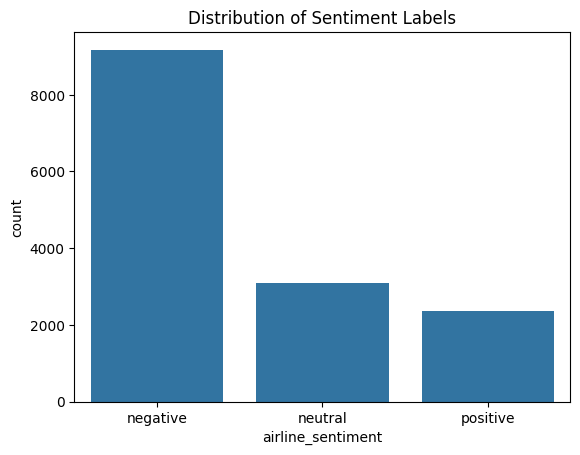

In [4]:
sns.countplot(
    data=df,
    x="airline_sentiment",
    order=df["airline_sentiment"].value_counts().index
)

plt.title("Distribution of Sentiment Labels")
plt.show()

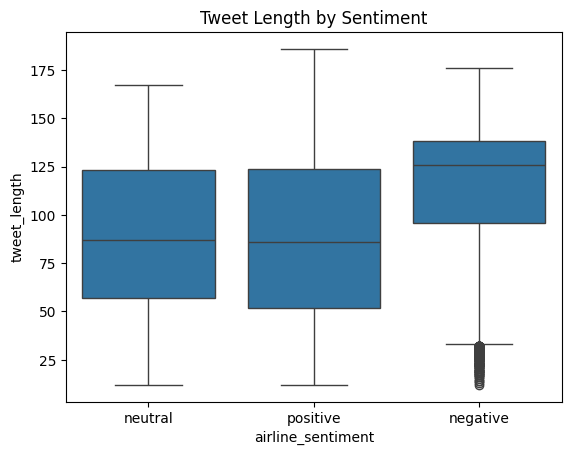

In [5]:
df["tweet_length"] = df["text"].apply(len)

sns.boxplot(
    data=df,
    x="airline_sentiment",
    y="tweet_length"
)

plt.title("Tweet Length by Sentiment")
plt.show()

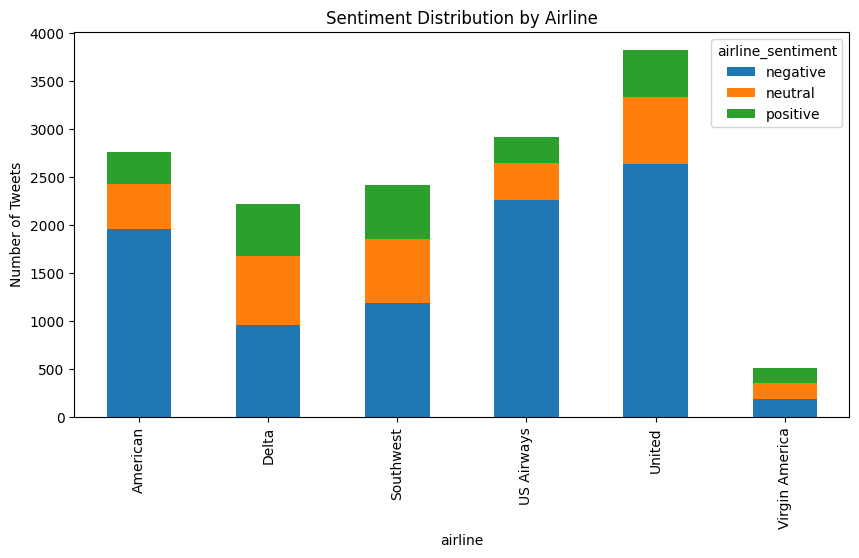

In [6]:
sentiment_airline = pd.crosstab(
    df["airline"],
    df["airline_sentiment"]
)

sentiment_airline.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Sentiment Distribution by Airline")
plt.ylabel("Number of Tweets")
plt.show()

## 3) Text Cleaning

Tweets often contain elements such as URLs, mentions, hashtags, and other informal structures.

Instead of applying aggressive text cleaning that might remove useful signals, we perform **minimal preprocessing**:

- URLs are replaced with a generic token.
- User mentions are normalized.
- Hashtag symbols are removed while keeping the associated word.

This strategy preserves as much semantic information as possible while reducing noise in the text data.

In [7]:

URL_RE = re.compile(r"http\S+|www\.\S+")
USER_RE = re.compile(r"@\w+")
MULTISPACE_RE = re.compile(r"\s+")

def clean_tweet(text: str) -> str:
    text = str(text)
    text = URL_RE.sub(" URL ", text)
    text = USER_RE.sub(" USER ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

df["text_clean"] = df[text_col].map(clean_tweet)
df[["text", "text_clean"]].sample(5, random_state=RANDOM_STATE)


,text,text_clean
4794,@SouthwestAir you're my early frontrunner for ...,USER you're my early frontrunner for best airl...
10480,@USAirways how is it that my flt to EWR was Ca...,USER how is it that my flt to EWR was Cancelle...
8067,@JetBlue what is going on with your BDL to DCA...,USER what is going on with your BDL to DCA fli...
8880,@JetBlue do they have to depart from Washingto...,"USER do they have to depart from Washington, D..."
8292,@JetBlue I can probably find some of them. Are...,USER I can probably find some of them. Are the...


## 4) Train/Test Split

To evaluate the generalization ability of our models, the dataset is divided into **training and testing subsets**.

A **stratified split** is used to maintain the original class distribution of the sentiment labels in both subsets.

All model training and feature extraction steps are performed only on the training data, while the test set is reserved exclusively for evaluation.

In [8]:

X = df["text_clean"]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(airline_sentiment
 negative    0.626952
 neutral     0.211651
 positive    0.161397
 Name: proportion, dtype: float64,
 airline_sentiment
 negative    0.626821
 neutral     0.211749
 positive    0.161430
 Name: proportion, dtype: float64)

## 5) Evaluation Utilities

To simplify model evaluation and maintain consistent reporting across experiments, we define utility functions that compute several key metrics.

The main metrics used are:

- **F1 Macro:** provides equal importance to all sentiment classes and is robust to class imbalance.
- **Balanced Accuracy:** accounts for differences in class frequency.
- **Confusion Matrix:** helps visualize which sentiment classes are commonly misclassified.

These tools allow us to compare different models in a clear and consistent way.

In [9]:

def evaluate_model(model, X_test, y_test, title: str = ""):
    pred = model.predict(X_test)
    f1_macro = f1_score(y_test, pred, average="macro")
    bal_acc = balanced_accuracy_score(y_test, pred)

    print(f"=== {title} ===")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"Balanced accuracy: {bal_acc:.4f}\n")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

    return {"model": title, "f1_macro": f1_macro, "balanced_accuracy": bal_acc}

def show_top_errors(model, X_test, y_test, n=10, random_state=42):
    pred = model.predict(X_test)
    mask = pred != y_test
    errs = pd.DataFrame({"text": X_test[mask], "y_true": y_test[mask], "y_pred": pred[mask]})
    if errs.empty:
        print("No errors found (unexpected).")
        return errs
    errs = errs.sample(min(n, len(errs)), random_state=random_state)
    return errs


## 6) Baseline Models

We begin with several baseline models commonly used in text classification:

- **Logistic Regression**
- **Linear Support Vector Machine (LinearSVC)**
- **Multinomial Naive Bayes**

Text is transformed into numerical features using **TF-IDF vectorization with word n-grams**.

Each model is implemented within a **scikit-learn Pipeline**, ensuring that text preprocessing and model training occur in a single reproducible workflow.

=== LogReg (TF-IDF word 1-2) ===
F1-macro: 0.7453
Balanced accuracy: 0.7551

              precision    recall  f1-score   support

    negative       0.89      0.84      0.86      2753
     neutral       0.60      0.71      0.65       930
    positive       0.73      0.72      0.72       709

    accuracy                           0.79      4392
   macro avg       0.74      0.76      0.75      4392
weighted avg       0.80      0.79      0.80      4392



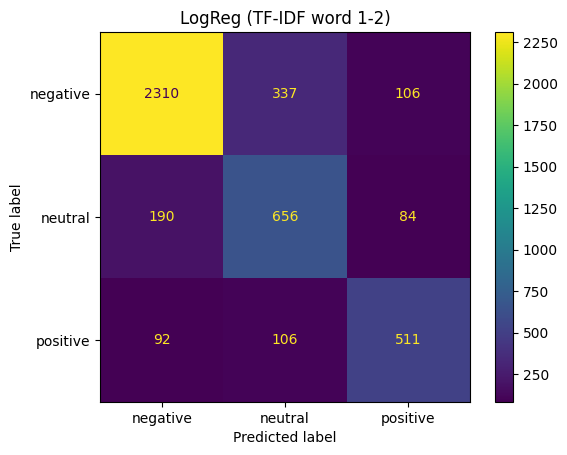

=== LinearSVC (TF-IDF word 1-2) ===
F1-macro: 0.7460
Balanced accuracy: 0.7379

              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      2753
     neutral       0.63      0.64      0.63       930
    positive       0.77      0.69      0.73       709

    accuracy                           0.80      4392
   macro avg       0.76      0.74      0.75      4392
weighted avg       0.80      0.80      0.80      4392



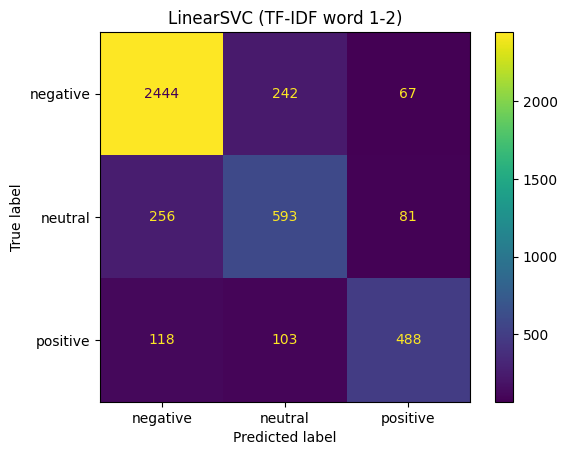

=== MultinomialNB (TF-IDF word 1-2) ===
F1-macro: 0.6071
Balanced accuracy: 0.5617

              precision    recall  f1-score   support

    negative       0.73      0.99      0.84      2753
     neutral       0.78      0.27      0.41       930
    positive       0.91      0.42      0.58       709

    accuracy                           0.75      4392
   macro avg       0.81      0.56      0.61      4392
weighted avg       0.77      0.75      0.71      4392



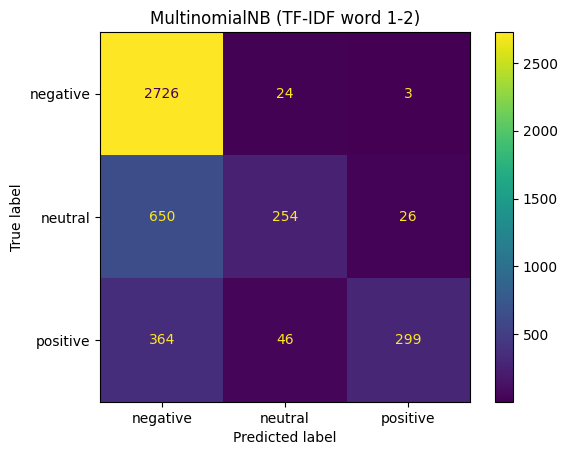

In [10]:
# 6.1 Logistic Regression + TF-IDF word ngrams
pipe_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe_logreg.fit(X_train, y_train)
res_logreg = evaluate_model(pipe_logreg, X_test, y_test, title="LogReg (TF-IDF word 1-2)")

# 6.2 Linear SVM + TF-IDF word ngrams
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

pipe_svm.fit(X_train, y_train)
res_svm = evaluate_model(pipe_svm, X_test, y_test, title="LinearSVC (TF-IDF word 1-2)")

# 6.3 MultinomialNB + TF-IDF
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", MultinomialNB(alpha=0.5))
])

pipe_nb.fit(X_train, y_train)
res_nb = evaluate_model(pipe_nb, X_test, y_test, title="MultinomialNB (TF-IDF word 1-2)")


## 7) Character n-grams

In social media text such as tweets, spelling variations, abbreviations, and punctuation patterns are common.

To capture these patterns, we experiment with **character-level n-grams**. Character features often improve robustness in noisy text environments because they capture subword information and stylistic cues.

=== LinearSVC (TF-IDF char 3-5) ===
F1-macro: 0.7509
Balanced accuracy: 0.7428

              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      2753
     neutral       0.65      0.65      0.65       930
    positive       0.77      0.70      0.73       709

    accuracy                           0.81      4392
   macro avg       0.76      0.74      0.75      4392
weighted avg       0.80      0.81      0.80      4392



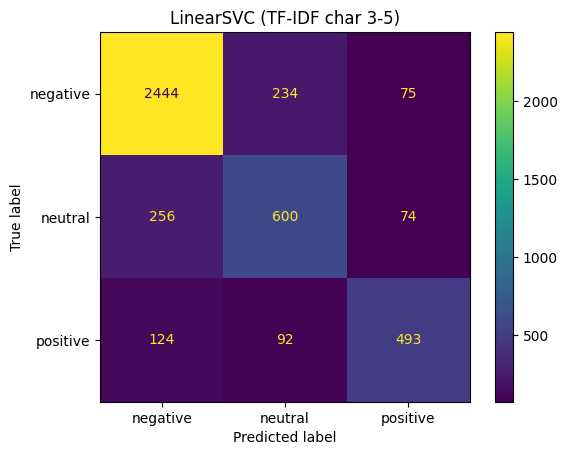

In [11]:
pipe_char_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=2
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

pipe_char_svm.fit(X_train, y_train)
res_char = evaluate_model(pipe_char_svm, X_test, y_test, title="LinearSVC (TF-IDF char 3-5)")


## 8) Combined Word and Character Features

To leverage the strengths of both representations, we combine **word-level n-grams** and **character-level n-grams**.

Word features capture semantic meaning, while character features capture stylistic and morphological patterns.

This combined representation can sometimes improve performance in short, noisy texts such as tweets.

=== LogReg (Word 1-2 + Char 3-5) ===
F1-macro: 0.7622
Balanced accuracy: 0.7712

              precision    recall  f1-score   support

    negative       0.90      0.86      0.88      2753
     neutral       0.63      0.72      0.67       930
    positive       0.74      0.74      0.74       709

    accuracy                           0.81      4392
   macro avg       0.76      0.77      0.76      4392
weighted avg       0.82      0.81      0.81      4392



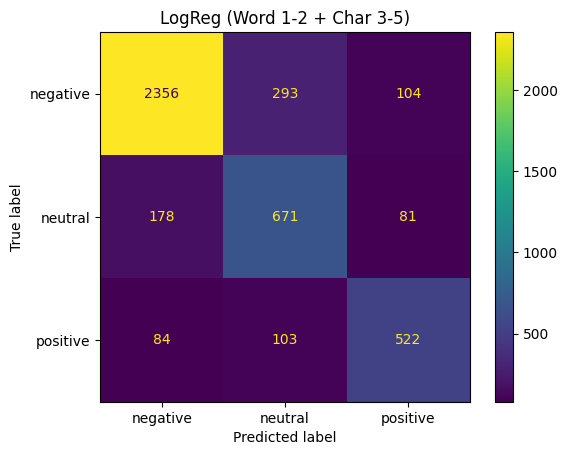

In [12]:
word_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)
char_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=2
)

pipe_combo = Pipeline([
    ("feats", FeatureUnion([
        ("word", word_vec),
        ("char", char_vec),
    ])),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

pipe_combo.fit(X_train, y_train)
res_combo = evaluate_model(pipe_combo, X_test, y_test, title="LogReg (Word 1-2 + Char 3-5)")


## 9) Model Comparison

After training several models, we compare their performance using F1 macro and balanced accuracy.

This comparison helps identify which feature representation and model combination performs best for this sentiment classification task.

Rather than focusing solely on overall accuracy, we pay attention to how well each model performs across all sentiment classes.

In [13]:
results = pd.DataFrame([res_logreg, res_svm, res_nb, res_char, res_combo]).sort_values("f1_macro", ascending=False)
results


,model,f1_macro,balanced_accuracy
4,LogReg (Word 1-2 + Char 3-5),0.762200,0.771182
3,LinearSVC (TF-IDF char 3-5),0.750946,0.742755
1,LinearSVC (TF-IDF word 1-2),0.745985,0.737896
0,LogReg (TF-IDF word 1-2),0.745269,0.755065
2,MultinomialNB (TF-IDF word 1-2),0.607147,0.561677


The results suggest that linear models with TF-IDF features perform strongly
for short social media texts.

LinearSVC achieved the best overall performance in terms of macro F1-score,
which indicates balanced performance across sentiment classes.

The relatively strong performance of character n-grams suggests that stylistic
signals such as punctuation, abbreviations, or informal spellings play an
important role in sentiment expression in Twitter data.

## 10) Hyperparameter Tuning

Once a promising model configuration has been identified, we apply **GridSearchCV** to tune its hyperparameters.

Grid search performs cross-validation over a predefined parameter grid and selects the configuration that maximizes the chosen scoring metric.

In this case, we optimize for **F1 macro**, which ensures balanced performance across sentiment categories.

In [14]:
pipe_svm_tuning = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(class_weight="balanced"))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1,2,5],
    "tfidf__max_df": [0.9, 0.95],
    "clf__C": [0.1, 1, 5]
}

grid = GridSearchCV(
    pipe_svm_tuning,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'clf__C': 1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.7419049586863522


=== LinearSVC tuned (GridSearch) ===
F1-macro: 0.7459
Balanced accuracy: 0.7275

              precision    recall  f1-score   support

    negative       0.85      0.92      0.88      2753
     neutral       0.68      0.58      0.63       930
    positive       0.78      0.68      0.73       709

    accuracy                           0.81      4392
   macro avg       0.77      0.73      0.75      4392
weighted avg       0.80      0.81      0.80      4392



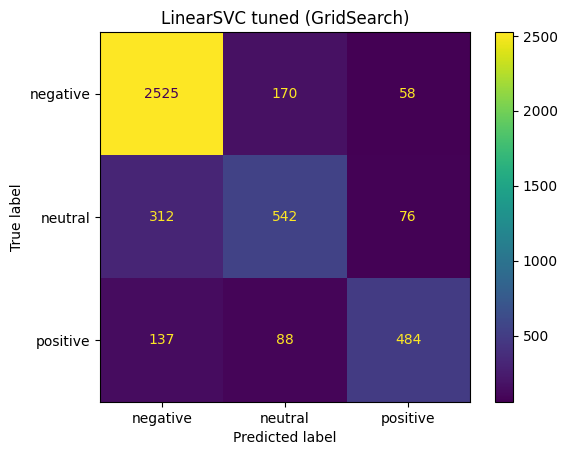

In [15]:
best_model = grid.best_estimator_

res_grid = evaluate_model(
    best_model,
    X_test,
    y_test,
    title="LinearSVC tuned (GridSearch)"
)

## 11) Model Interpretability: Top TF-IDF Features

Understanding which textual features drive model predictions is important for
interpreting the behavior of machine learning classifiers.

For linear models such as Logistic Regression or Linear SVM, the learned
coefficients provide information about which terms are most strongly
associated with each sentiment class.

By inspecting the highest positive and negative coefficients, we can identify
which words contribute most strongly to positive or negative sentiment
predictions in the dataset.

This analysis helps connect the statistical model with the linguistic patterns
present in the tweets.

In [16]:
feature_names = pipe_logreg.named_steps["tfidf"].get_feature_names_out()
coefficients = pipe_logreg.named_steps["clf"].coef_

top_positive = np.argsort(coefficients[0])[-20:]
top_negative = np.argsort(coefficients[0])[:20]

print("Top positive words:")
print(feature_names[top_positive])

print("\nTop negative words:")
print(feature_names[top_negative])

Top positive words:
['still' 'and' 'call' 'been' 'because' 'luggage' 'nothing' 'again' 'hold'
 'why' 'delay' 'on hold' 'hour' 'cancelled' 'worst' 'your' 'delayed'
 'hours' 'no' 'not']

Top negative words:
['thanks' 'thank' 'thank you' 'great' 'love' 'url' 'amazing' 'awesome'
 'good' 'best' 'worries' 'no worries' 'user thank' 'will' 'the best'
 'destinationdragons' 'follow' 'that why' 'user is' 'thx']


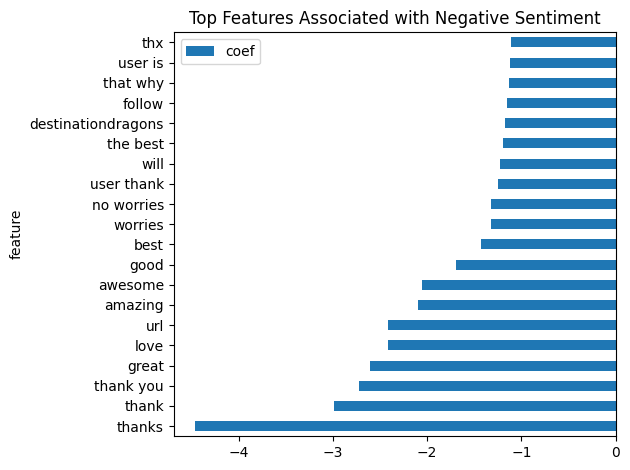

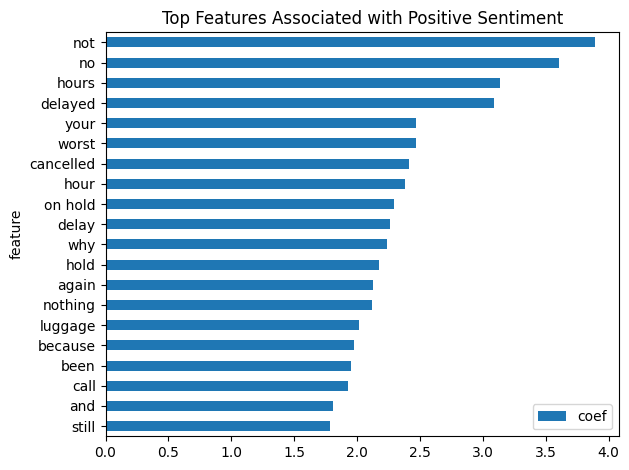

In [17]:
top_features = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients[0]
}).sort_values("coef")

top_features.head(20).plot.barh(x="feature", y="coef")
plt.title("Top Features Associated with Negative Sentiment")
plt.tight_layout()
plt.show()

top_features.tail(20).plot.barh(x="feature", y="coef")
plt.title("Top Features Associated with Positive Sentiment")
plt.tight_layout()
plt.show()

### Interpretation of TF-IDF Features

The learned coefficients provide insight into which words the model associates with each sentiment category.

Terms such as **"delay", "cancelled", "hold", "hours", and "delayed"** appear among the strongest predictors of negative sentiment. These words reflect typical customer complaints in airline-related tweets and often correspond to operational disruptions experienced by passengers.

In contrast, words such as **"thanks", "great", "awesome", "love", and "best"** are strongly associated with positive sentiment. These expressions typically appear in tweets describing positive customer experiences or successful interactions with airline support.

Interestingly, several negation-related terms such as **"not"** and **"no"** also appear among influential features. This highlights the importance of contextual expressions such as "not good" or "no response", which are common patterns in complaint-related tweets.

Overall, the feature analysis suggests that the model is capturing meaningful linguistic signals related to customer satisfaction and service failures. From a behavioral perspective, these terms reflect how customers express dissatisfaction or appreciation in real-world service interactions.

## 11) Error Analysis

Beyond quantitative metrics, it is important to examine specific examples where the model makes incorrect predictions.

By reviewing misclassified tweets we can identify common sources of error, such as:

- sarcasm or irony,
- implicit context,
- ambiguous sentiment,
- or subtle distinctions between neutral and negative tweets.

This qualitative analysis provides insights into the limitations of the model and helps guide potential improvements.

In [18]:
best_model_name = results.iloc[0]["model"]
best_model = {
    "LogReg (TF-IDF word 1-2)": pipe_logreg,
    "LinearSVC (TF-IDF word 1-2)": pipe_svm,
    "MultinomialNB (TF-IDF word 1-2)": pipe_nb,
    "LinearSVC (TF-IDF char 3-5)": pipe_char_svm,
    "LogReg (Word 1-2 + Char 3-5)": pipe_combo
}[best_model_name]

errs = show_top_errors(best_model, X_test, y_test, n=12, random_state=42)
errs


,text,y_true,y_pred
12130,USER USER we done it with 1 truck... No biggie 😄,positive,neutral
2717,USER can you let us out of the gate now. UA1157,negative,neutral
10487,"USER thank you! It's # 1875 from BWI, keep see...",positive,neutral
13748,"USER Thanks, she did her best. Staying the nig...",negative,positive
11518,USER I don't need to rebook I need to know the...,negative,neutral
7488,USER I'm over that honestly just would like to...,negative,neutral
4706,USER Just landed in PHL. Row 9 window cover on...,negative,neutral
14100,"USER USER ""here for you"" as in, yeah, we'll tw...",negative,neutral
1320,USER - Group 2 line gets longer every week. Al...,neutral,negative
8038,USER Of course U know I would like 2 lay you d...,positive,neutral


Error inspection reveals several common challenges in sentiment classification:

• Tweets containing sarcasm or irony
• Context-dependent expressions
• Short ambiguous statements

For example, some tweets labeled as neutral contain implicit complaints
that are difficult for a model based purely on n-gram features to capture.

These errors highlight the limitations of traditional bag-of-words
approaches and suggest that contextual language models could further
improve performance.

## 12) VADER Sentiment Baseline

In addition to the supervised machine learning models, we apply **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, a rule-based sentiment analysis tool specifically designed for social media text.

VADER assigns polarity scores to a piece of text using a predefined sentiment lexicon and heuristic rules that account for punctuation, capitalization, and intensifiers. The main output is the **compound score**, which ranges from **-1 (most negative)** to **+1 (most positive)**.

Unlike the supervised models used earlier in the notebook, VADER does **not require training data**. Instead, it provides a lexicon-based estimate of sentiment that can serve as a useful baseline.

In this analysis, the VADER compound score is used to:

- explore the distribution of sentiment across tweets,
- compare sentiment patterns across airlines,
- and provide a reference point for evaluating how much additional signal is captured by machine learning models.

While lexicon-based approaches are generally less flexible than supervised models, they can still offer valuable insights into the overall sentiment structure of the dataset.

In [19]:
sid = SentimentIntensityAnalyzer()

vader_scores = df["text_clean"].apply(lambda t: sid.polarity_scores(t))
vader_df = pd.DataFrame(list(vader_scores))

df_vader = pd.concat([df, vader_df], axis=1)

display(df_vader.groupby("airline_sentiment")["compound"].describe())

if "airline" in df_vader.columns:
    display(df_vader.groupby("airline")["compound"].mean().sort_values())

,count,mean,std,min,25%,50%,75%,max
airline_sentiment,,,,,,,,
negative,9178.0,-0.115740,0.431688,-0.9668,-0.4713,-0.0772,0.1761,0.9716
neutral,3099.0,0.152849,0.328470,-0.8957,0.0000,0.0000,0.4199,0.9749
positive,2363.0,0.543932,0.312272,-0.8617,0.4199,0.6249,0.7835,0.9760


,compound
airline,
US Airways,-0.031465
American,0.007499
United,0.026250
Delta,0.125055
Southwest,0.132723
Virgin America,0.135527


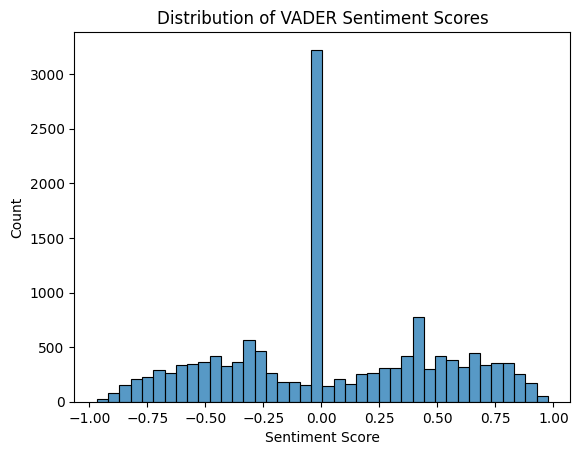

In [20]:
sns.histplot(df_vader["compound"], bins=40)

plt.title("Distribution of VADER Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.show()

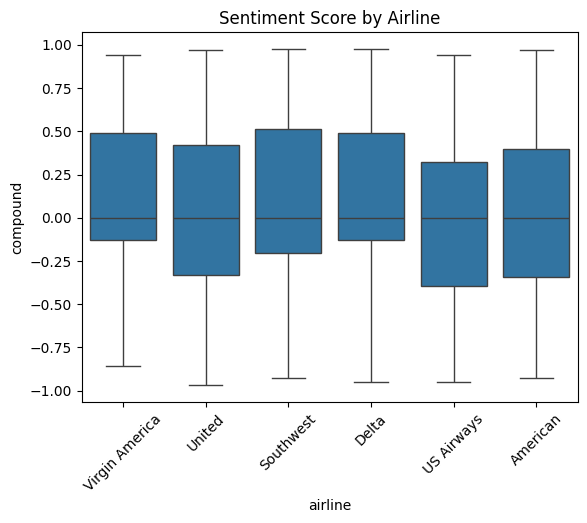

In [21]:
sns.boxplot(
    data=df_vader,
    x="airline",
    y="compound"
)

plt.xticks(rotation=45)
plt.title("Sentiment Score by Airline")
plt.show()

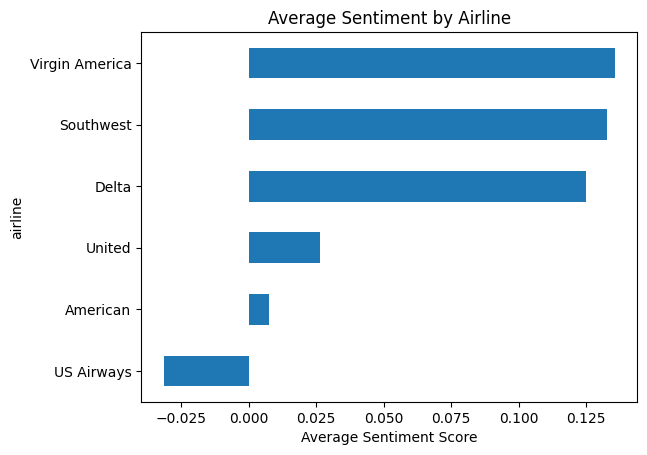

In [22]:
sentiment_airline = df_vader.groupby("airline")["compound"].mean().sort_values()

sentiment_airline.plot(kind="barh")

plt.title("Average Sentiment by Airline")
plt.xlabel("Average Sentiment Score")
plt.show()

## 13) NLP Visualizations

Finally, we explore the textual data using several visualizations:

- **WordClouds** to highlight frequently used terms,
- **Word frequency analysis** to identify common words associated with different sentiment categories,
- **Sentiment distributions** to better understand patterns in the dataset.
- **Top words per sentiment**

These visualizations help connect the model results with the underlying linguistic patterns present in the tweets.

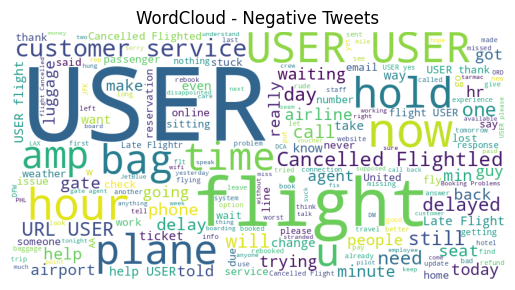

In [23]:
negative_text = " ".join(
    df[df["airline_sentiment"]=="negative"]["text_clean"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud - Negative Tweets")
plt.show()

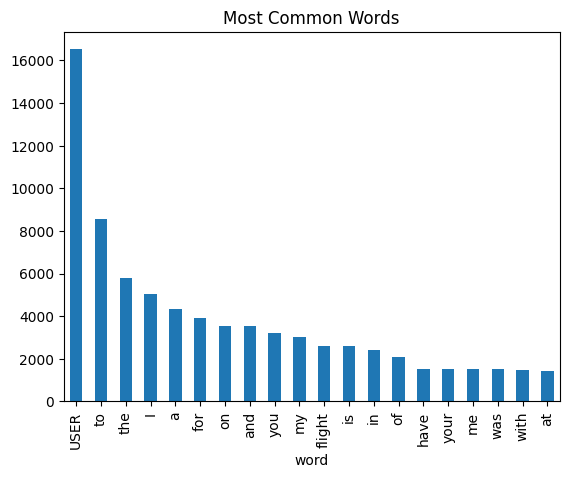

In [24]:
words = " ".join(df["text_clean"]).split()

common = Counter(words).most_common(20)

pd.DataFrame(common, columns=["word","count"]).plot.bar(
    x="word",
    y="count",
    legend=False
)

plt.title("Most Common Words")
plt.show()

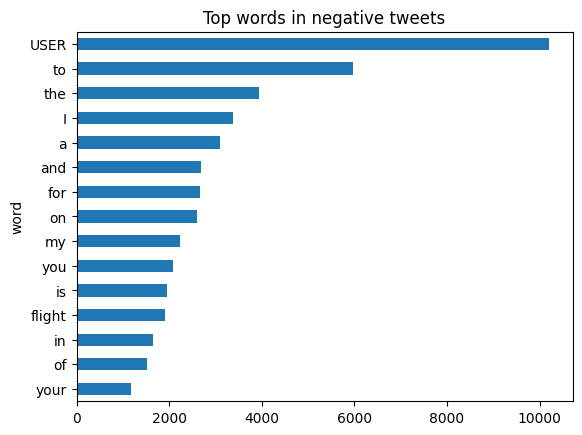

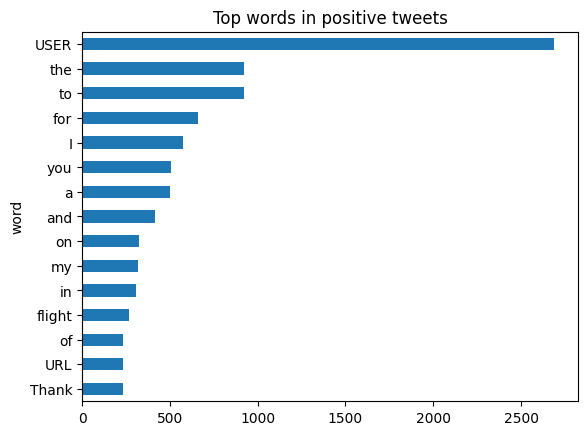

In [25]:
def plot_top_words(sentiment, n=15):

    text = " ".join(
        df[df["airline_sentiment"]==sentiment]["text_clean"]
    )

    words = text.split()
    common = Counter(words).most_common(n)

    words_df = pd.DataFrame(common, columns=["word","count"])

    words_df.plot.barh(
        x="word",
        y="count",
        legend=False
    )

    plt.title(f"Top words in {sentiment} tweets")
    plt.gca().invert_yaxis()
    plt.show()


plot_top_words("negative")
plot_top_words("positive")

### Top Words by Sentiment

To better understand the language patterns associated with each sentiment class, we analyze the most frequent words appearing in tweets labeled as positive, neutral, and negative.

This analysis helps identify the types of expressions commonly used in different sentiment contexts and complements the model-based interpretation presented earlier.

By examining these frequent terms, we can also better understand the behavioral signals present in customer feedback.

In [26]:

def get_top_words(text_series, n=15):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

top_negative = get_top_words(df[df["airline_sentiment"]=="negative"]["text_clean"])
top_positive = get_top_words(df[df["airline_sentiment"]=="positive"]["text_clean"])
top_neutral = get_top_words(df[df["airline_sentiment"]=="neutral"]["text_clean"])

print("Top words - Negative sentiment")
print(top_negative)

print("\nTop words - Positive sentiment")
print(top_positive)

print("\nTop words - Neutral sentiment")
print(top_neutral)

Top words - Negative sentiment
[('USER', 10199), ('to', 5966), ('the', 3930), ('I', 3375), ('a', 3087), ('and', 2685), ('for', 2665), ('on', 2593), ('my', 2225), ('you', 2092), ('is', 1959), ('flight', 1920), ('in', 1644), ('of', 1514), ('your', 1182)]

Top words - Positive sentiment
[('USER', 2690), ('the', 924), ('to', 923), ('for', 658), ('I', 574), ('you', 509), ('a', 501), ('and', 416), ('on', 327), ('my', 320), ('in', 309), ('flight', 265), ('of', 236), ('URL', 233), ('Thank', 231)]

Top words - Neutral sentiment
[('USER', 3616), ('to', 1646), ('I', 1105), ('the', 928), ('a', 771), ('you', 631), ('on', 631), ('for', 598), ('URL', 526), ('my', 490), ('in', 445), ('and', 443), ('flight', 419), ('is', 401), ('of', 343)]


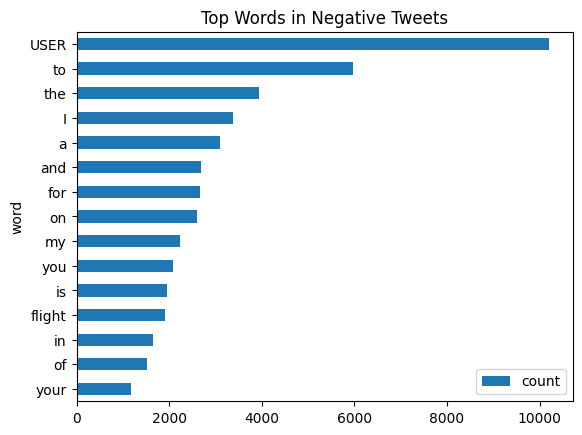

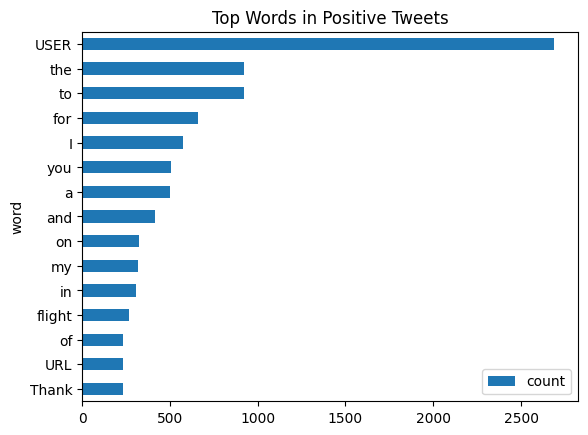

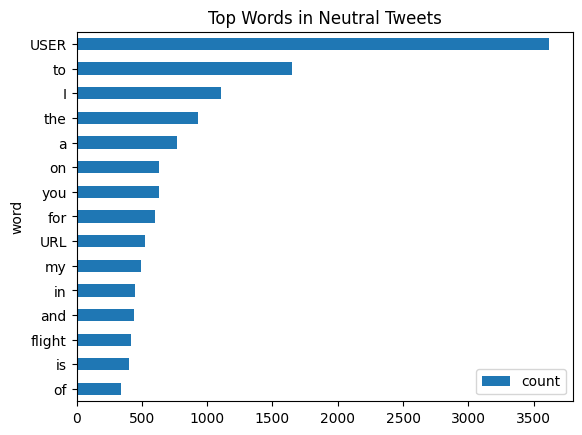

In [27]:

def plot_top_words(word_counts, title):
    words, counts = zip(*word_counts)
    df_plot = pd.DataFrame({"word": words, "count": counts})

    df_plot.sort_values("count").plot.barh(x="word", y="count")
    plt.title(title)
    plt.show()

plot_top_words(top_negative, "Top Words in Negative Tweets")
plot_top_words(top_positive, "Top Words in Positive Tweets")
plot_top_words(top_neutral, "Top Words in Neutral Tweets")

### Interpretation

The most frequent words across sentiment categories consist mainly of common function words such as "to", "the", "I", and "and", as well as tokens introduced during preprocessing such as "USER" and "URL".

This pattern is expected in frequency-based analyses, as highly frequent words tend to dominate the distribution regardless of sentiment category.

As a result, these frequent terms provide limited insight into sentiment-specific language patterns. Instead, they primarily reflect the structural characteristics of tweet-based communication and the conversational nature of Twitter interactions.

More informative linguistic signals are captured through TF-IDF based feature analysis, which highlights words that are more discriminative for sentiment prediction, such as "delay", "cancelled", or "hold".

This highlights the importance of weighting schemes such as TF-IDF, which down-weight very common terms and emphasize words that are more discriminative for classification.


However, simple frequency-based analyses have important limitations.

Highly frequent words are not necessarily informative for sentiment classification. Many of the most common tokens correspond to grammatical structure rather than sentiment-bearing language.

For this reason, more informative insights can be obtained from TF-IDF based feature analysis or from examining model coefficients, which highlight words that are more discriminative for sentiment prediction.

## Conclusions

This analysis demonstrates how classical NLP techniques combined with machine learning can effectively classify sentiment in short social media texts.

Several key findings emerge from the modeling process:

- Linear models combined with **TF-IDF representations** provide strong and reliable baselines for sentiment classification tasks.
- **Character n-grams** improve robustness when dealing with noisy and informal text typical of social media environments.
- Because the dataset is moderately imbalanced, evaluation metrics such as **F1 macro** and **balanced accuracy** are more informative than simple accuracy.

The inspection of model features and prediction errors suggests that the classifier captures meaningful linguistic signals associated with customer experience. Many of the strongest negative predictors correspond to **operational disruptions** such as *delay*, *cancelled*, and *hold*, indicating that service reliability issues are a primary driver of negative sentiment in airline-related social media conversations.

Overall, the workflow presented in this notebook illustrates a reproducible approach to sentiment analysis, combining exploratory analysis, feature engineering, supervised modeling, and interpretability techniques.

---

## Limitations

Despite the overall performance of the models, several limitations should be considered when interpreting the results.

First, sentiment classification based on n-gram representations may struggle with **sarcasm, irony, or implicit sentiment**, which often require deeper contextual understanding.  
Second, tweets are typically **very short texts**, which limits the amount of contextual information available to the model.  
Finally, sentiment expressed in a tweet may depend on **external context** (previous interactions, service history, or conversational threads) that is not available in the dataset.

These factors highlight the inherent difficulty of sentiment analysis in social media environments.

---

## Future Work

Several extensions could further improve the analysis.

One direction would be to experiment with **transformer-based language models** such as BERT, RoBERTa, or BERTweet, which capture contextual relationships between words more effectively than traditional bag-of-words approaches.

Another potential improvement would be to incorporate **contextual embeddings**, allowing the model to represent semantic relationships beyond simple n-gram frequency.

Finally, additional exploratory techniques such as **topic modeling** or **temporal sentiment analysis** could help uncover broader patterns in customer complaints and satisfaction over time.

# Research framing

This analysis can be framed as a behavioral signal extraction problem.

Customer complaints on social media represent spontaneous expressions of
service dissatisfaction. By modeling sentiment in airline-related tweets,
we attempt to capture patterns in customer perception and service experience.

From a behavioral science perspective, negative sentiment often reflects
service failures such as delays, cancellations, or poor communication.

Therefore, sentiment analysis can be used as a proxy indicator of customer
experience and service quality.

##  ===== Recommended web pages =====

https://www.datacamp.com/tutorial/text-analytics-beginners-nltk

https://stackabuse.com/removing-stop-words-from-strings-in-python/

https://www.arsys.es/blog/analisis-sentimientos-python-jupyter-notebooks

https://www.datacamp.com/tutorial/text-analytics-beginners-nltk

https://pharos.sh/python-para-pnl-analisis-de-sentimiento-con-scikit-learn/


https://unipython.com/como-limpiar-el-texto-manualmente-usando-nltk/

https://stackoverflow.com/questions/33098040/how-to-use-word-tokenize-in-data-frame

https://www.red-gate.com/simple-talk/development/data-science-development/sentiment-analysis-python/